<a href="https://colab.research.google.com/github/liminalvoid/nlp/blob/main/sem_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Семинар 2. Domain Shift, наивный Байес, метрики

## Domain Shift/распределения

### Исходные датасеты

В качестве исходных датасетов используются `data-silence/rus_news_classifier` для классификации новостных текстов и `Kostya165/ru_emotion_dvach` для классификации эмоционального интента.

In [75]:
from datasets import load_dataset


rus_news_ds = load_dataset("data-silence/rus_news_classifier")
ru_emotion_ds = load_dataset("Kostya165/ru_emotion_dvach")

rus_news_ds, ru_emotion_ds

(DatasetDict({
     train: Dataset({
         features: ['news', 'labels'],
         num_rows: 57530
     })
     test: Dataset({
         features: ['news', 'labels'],
         num_rows: 14383
     })
 }),
 DatasetDict({
     train: Dataset({
         features: ['text', 'label'],
         num_rows: 59061
     })
     validation: Dataset({
         features: ['text', 'label'],
         num_rows: 2507
     })
 }))

### Топ-30 log-odds токенов

Извлечение подвыборок из каждого датасета размером 3000 строк.

In [76]:
import numpy as np


def sample_tests(ds, split, n=2000, text_key="text"):
    idx = np.random.choice(len(ds[split]), size=min(n, len(ds[split])), replace=False)

    return [ds[split][int(i)][text_key] for i in idx]


rus_news_train = sample_tests(rus_news_ds, "train", n=3000, text_key="news")
emotion_train = sample_tests(ru_emotion_ds, "train", n=3000)

print("rus_news sampled:", len(rus_news_train))
print("emotion sampled:", len(emotion_train))

rus_news sampled: 3000
emotion sampled: 3000


Вспомогательные функции для калькуляции log-odds.

In [77]:
import re
import math

from collections import Counter
from typing import List


TOKEN_RE = re.compile(r"[А-Яа-яЁё]+(?:-[А-Яа-яЁё]+)?")
simple_tokenize = lambda text, regex: regex.findall(text.lower())


def log_odds_with_smoothing(counts_a: Counter, counts_b: Counter, alpha: float = 0.1):
    """Δ(w)=log((c_a(w)+α)/(N_a+α|V|)) - log((c_b(w)+α)/(N_b+α|V|))"""
    vocab = set(counts_a) | set(counts_b)
    V = len(vocab)
    Na = sum(counts_a.values())
    Nb = sum(counts_b.values())
    deltas = {}

    for w in vocab:
        pa = (counts_a[w] + alpha) / (Na + alpha * V)
        pb = (counts_b[w] + alpha) / (Nb + alpha * V)
        deltas[w] = math.log(pa) - math.log(pb)

    return deltas


def get_tokens(texts, regex=TOKEN_RE):
    for t in texts:
        if t:
            yield from simple_tokenize(t, regex)


def top_log_odds_words(
        texts_a: Counter,
        texts_b: Counter,
        top_n: int = 25,
        alpha: float = 0.1
):
    """
    Функция для калькуляции log-odds для токенов.
    """
    deltas = log_odds_with_smoothing(texts_a, texts_b, alpha=alpha)
    pos = sorted(deltas.items(), key=lambda x: x[1], reverse=True)[:top_n]
    neg = sorted(deltas.items(), key=lambda x: x[1])[:top_n]

    return pos, neg

Log-odds для подвыборок.

In [78]:
import pandas as pd


rus_news_cnt = Counter(get_tokens(rus_news_train))
ru_emotion_cnt = Counter(get_tokens(emotion_train))
pos, neg = top_log_odds_words(rus_news_cnt, ru_emotion_cnt, top_n=30)

rus_news_vs_emotions = pd.DataFrame(pos, columns=["word", "∆(rus_news - emotion)"])
emotions_vs_rus_news = pd.DataFrame(neg, columns=["word", "∆(emotion - rus_news)"])

print("Топ-слова для rus_news (против emotion):")
display(rus_news_vs_emotions)

print("Топ-слова для emotion (против rus_news):")
display(emotions_vs_rus_news)

Топ-слова для rus_news (против emotion):


,word,∆(rus_news - emotion)
0,словам,7.464300
1,отметил,6.679385
2,процента,6.582840
3,рассказал,6.547675
4,сообщалось,6.465662
5,глава,6.315002
6,сообщил,6.183232
7,риа,6.133944
8,отмечается,6.123058
9,издание,6.123058


Топ-слова для emotion (против rus_news):


,word,∆(emotion - rus_news)
0,замечательно,-8.750517
1,идиоты,-7.624902
2,переживаю,-7.532813
3,идиот,-7.277817
4,знаешь,-7.277817
5,хохлы,-6.991517
6,замечательная,-6.874424
7,русачков,-6.874424
8,смотрите-ка,-6.810299
9,чём,-6.810299


### Графики распределений

Увеличение размера графиков.

In [79]:
import matplotlib.pyplot as plt


plt.rcParams["figure.dpi"] = 140

#### Распределение длины документов

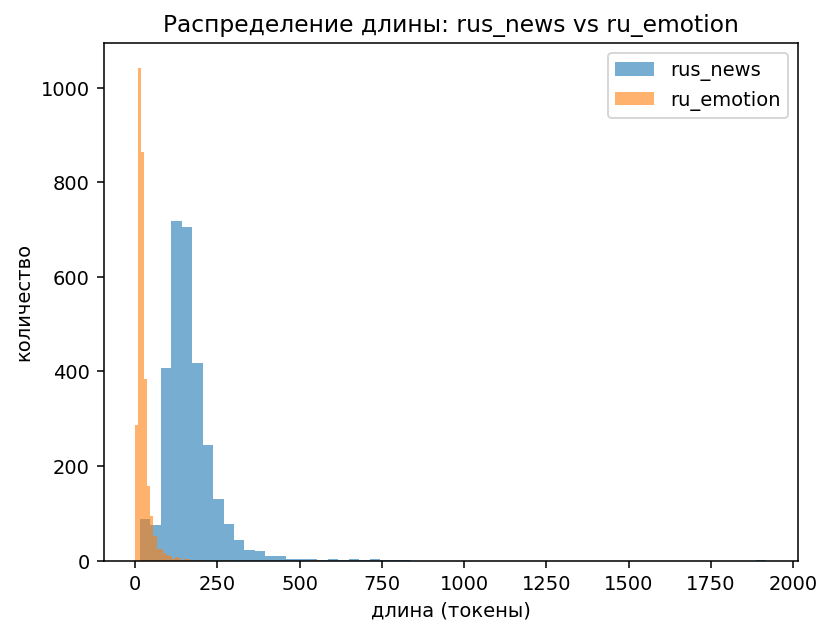

In [80]:
plt.figure()
plt.hist(
    [len(simple_tokenize(t, TOKEN_RE)) for t in rus_news_train if t],
    bins=60,
    alpha=0.6,
    label="rus_news",
)
plt.hist(
    [len(simple_tokenize(t, TOKEN_RE)) for t in emotion_train if t],
    bins=60,
    alpha=0.6,
    label="ru_emotion",
)
plt.legend()
plt.title("Распределение длины: rus_news vs ru_emotion")
plt.xlabel("длина (токены)")
plt.ylabel("количество")
plt.show()

#### Закон Ципфа (частоты топ-100 токенов)

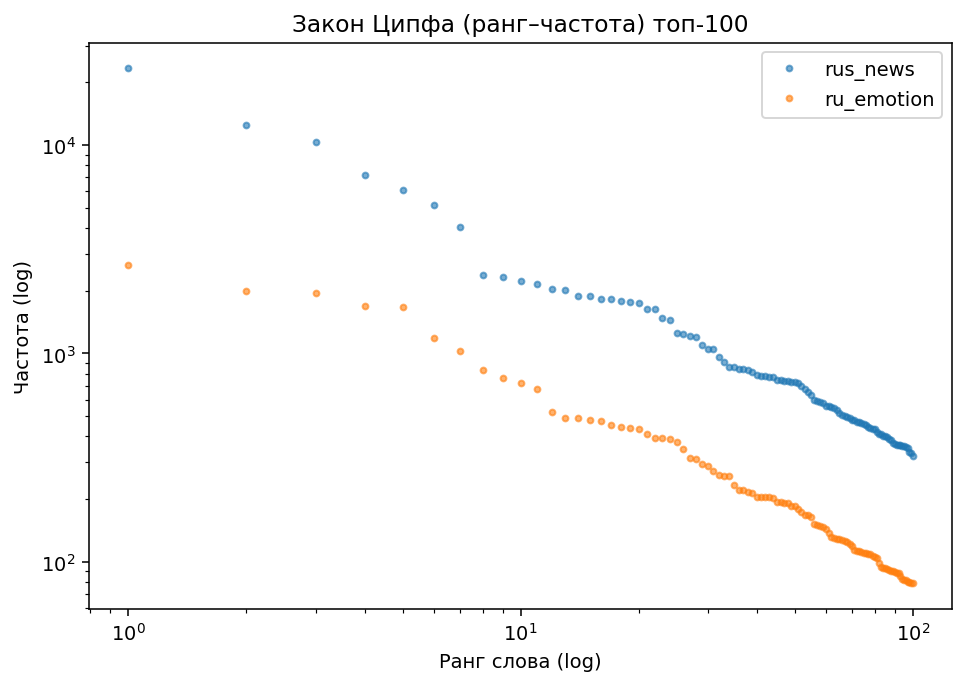

In [81]:
news_freqs_sorted = np.array([v for _, v in rus_news_cnt.most_common(100)])
news_ranks = np.arange(1, len(news_freqs_sorted) + 1)

emotion_freqs_sorted = np.array([v for _, v in ru_emotion_cnt.most_common(100)])
emotion_ranks = np.arange(1, len(emotion_freqs_sorted) + 1)

# 3.1 Zipf log-log
plt.figure(figsize=(7,5))
# news
plt.loglog(
    news_ranks,
    news_freqs_sorted,
    marker=".",
    linestyle="none",
    label="rus_news",
    alpha=0.6,
)
# emotion
plt.loglog(
    emotion_ranks,
    emotion_freqs_sorted,
    marker=".",
    linestyle="none",
    label="ru_emotion",
    alpha=0.6,
)
plt.legend()
plt.title("Закон Ципфа (ранг–частота) топ-100")
plt.xlabel("Ранг слова (log)")
plt.ylabel("Частота (log)")
plt.tight_layout()
plt.show()

#### Доля чисел/пунктуации

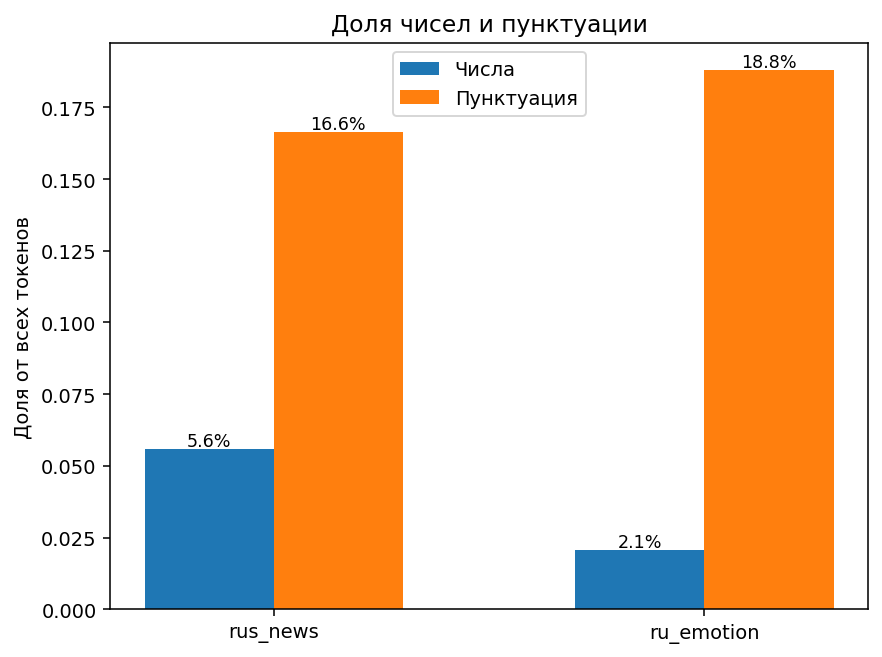

In [82]:
PUNCTUATION_REGEX = re.compile(r"[^\w\s]+")
DIGIT_REGEX = re.compile(r"\d")

rus_news_punctuation_tokens = Counter(get_tokens(rus_news_train, regex=PUNCTUATION_REGEX))
rus_news_digit_tokens = Counter(get_tokens(rus_news_train, regex=DIGIT_REGEX))

emotion_punctuation_tokens = Counter(get_tokens(emotion_train, regex=PUNCTUATION_REGEX))
emotion_digit_tokens = Counter(get_tokens(emotion_train, regex=DIGIT_REGEX))

rus_news_total_tokens = rus_news_cnt.total() + rus_news_digit_tokens.total() + rus_news_punctuation_tokens.total()
emotion_total_tokens = ru_emotion_cnt.total() + emotion_digit_tokens.total() + emotion_punctuation_tokens.total()

news_num = rus_news_digit_tokens.total() / rus_news_total_tokens
news_punct = rus_news_punctuation_tokens.total() / rus_news_total_tokens
emotion_num = emotion_digit_tokens.total() / emotion_total_tokens
emotion_punct = emotion_punctuation_tokens.total() / emotion_total_tokens

labels = ["rus_news", "ru_emotion"]

x = np.arange(len(labels))
width = 0.3

fig, ax = plt.subplots()
ax.bar(
    x - width/2,
    [news_num, emotion_num],
    width,
    label="Числа",
)
ax.bar(
    x + width/2,
    [news_punct, emotion_punct],
    width,
    label="Пунктуация",
)
for i, (n, p) in enumerate(zip([news_num, emotion_num], [news_punct, emotion_punct])):
    ax.text(i - width/2, n + 0.001, f"{n:.1%}", ha='center', fontsize=9)
    ax.text(i + width/2, p + 0.001, f"{p:.1%}", ha='center', fontsize=9)
ax.set_ylabel("Доля от всех токенов")
ax.set_title("Доля чисел и пунктуации")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.tight_layout()
plt.show()

#### Размер словаря

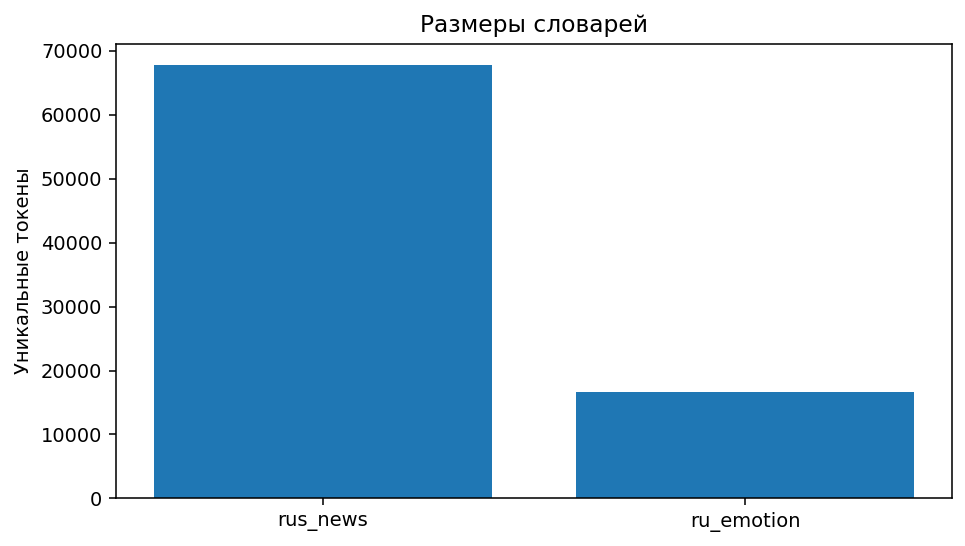

In [83]:
x = np.arange(2)

rus_news_dict_size = len(rus_news_cnt)
emotion_dict_size = len(ru_emotion_cnt)

plt.figure(figsize=(7,4))
plt.bar(
    ["rus_news", "ru_emotion"],
    [rus_news_dict_size, emotion_dict_size],
)
plt.title("Размеры словарей")
plt.ylabel("Уникальные токены")
plt.tight_layout()
plt.show()

### Лемматизация, n-граммы и стоп-слова

#### Лемматизация

In [84]:
!pip -q install pymorphy3 pymorphy3-dicts-ru

In [85]:
import pymorphy3


morph = pymorphy3.MorphAnalyzer()

rus_news_lemmas_cnt = Counter([morph.parse(w)[0].normal_form for w in get_tokens(rus_news_train)])
emotions_lemmas_cnt = Counter([morph.parse(w)[0].normal_form for w in get_tokens(emotion_train)])

Сравнение после лемматизации.

In [86]:
pos, neg = top_log_odds_words(rus_news_lemmas_cnt, emotions_lemmas_cnt, top_n=30)

rus_news_vs_emotion_lemmas = pd.DataFrame(pos, columns=["word (after lemmatization)", "∆(rus_news - emotion)"])
emotion_vs_rus_news_lemmas = pd.DataFrame(neg, columns=["word (after lemmatization)", "∆(emotion - rus_news)"])

print("Топ-слова для rus_news (против emotion):")
display(rus_news_vs_emotion_lemmas)

print("Топ-слова для emotion (против rus_news):")
display(emotion_vs_rus_news_lemmas)

Топ-слова для rus_news (против emotion):


,word (after lemmatization),∆(rus_news - emotion)
0,сообщаться,6.844404
1,издание,6.790346
2,коронавирус,6.411490
3,подчеркнуть,6.338208
4,октябрь,6.262170
5,отмечаться,6.192982
6,сентябрь,6.186448
7,июль,6.142904
8,июнь,6.115134
9,риа,6.090187


Топ-слова для emotion (против rus_news):


,word (after lemmatization),∆(emotion - rus_news)
0,идиот,-8.360339
1,хохол,-7.510100
2,гений,-7.089050
3,русачок,-6.918181
4,смотреть-ка,-6.854057
5,нахуй,-6.785537
6,пидорашка,-6.785537
7,пиздец,-6.711974
8,ха-ха,-6.711974
9,блядь,-6.632568


#### Разбиение на n-граммы

In [87]:
import nltk


rus_news_bigrams = Counter(nltk.ngrams(get_tokens(rus_news_train), n=2))
rus_news_trigrams = Counter(nltk.ngrams(get_tokens(rus_news_train), n=3))

ru_emotion_bigrams = Counter(nltk.ngrams(get_tokens(emotion_train), n=2))
ru_emotion_trigrams = Counter(nltk.ngrams(get_tokens(emotion_train), n=3))

Сравнение после разбиения на биграммы.

In [88]:
pos, neg = top_log_odds_words(rus_news_bigrams, ru_emotion_bigrams, top_n=30)

rus_news_vs_emotion_bigrams = pd.DataFrame(pos, columns=["word (bigrams)", "∆(rus_news - emotion)"])
emotion_vs_rus_news_bigrams = pd.DataFrame(neg, columns=["word (bigrams)", "∆(emotion - rus_news)"])

print("Топ-слова для rus_news (против emotion):")
display(rus_news_vs_emotion_bigrams)

print("Топ-слова для emotion (против rus_news):")
display(emotion_vs_rus_news_bigrams)

Топ-слова для rus_news (против emotion):


,word (bigrams),∆(rus_news - emotion)
0,"(этом, сообщает)",7.202048
1,"(по, словам)",7.197283
2,"(по, его)",6.652012
3,"(сообщалось, что)",6.604196
4,"(стало, известно)",6.424809
5,"(ранее, в)",6.400383
6,"(его, словам)",6.396845
7,"(отметил, что)",6.378962
8,"(риа, новости)",6.349666
9,"(отмечается, что)",6.223065


Топ-слова для emotion (против rus_news):


,word (bigrams),∆(emotion - rus_news)
0,"(боюсь, что)",-8.718890
1,"(я, боюсь)",-8.613615
2,"(ну, конечно)",-8.195690
3,"(ну, да)",-8.128641
4,"(о, конечно)",-7.995308
5,"(бы, мог)",-7.979333
6,"(мог, подумать)",-7.963099
7,"(а, вдруг)",-7.963099
8,"(просто, замечательно)",-7.841421
9,"(ты, что)",-7.681400


Сравнение после разбиения на триграммы.

In [89]:
pos, neg = top_log_odds_words(rus_news_trigrams, ru_emotion_trigrams, top_n=30)

rus_news_vs_emotion_trigrams = pd.DataFrame(pos, columns=["word (trigrams)", "∆(rus_news - emotion)"])
emotion_vs_rus_news_trigrams = pd.DataFrame(neg, columns=["word (trigrams)", "∆(emotion - rus_news)"])

print("Топ-слова для rus_news (против emotion):")
display(rus_news_vs_emotion_trigrams)

print("Топ-слова для emotion (против rus_news):")
display(emotion_vs_rus_news_trigrams)

Топ-слова для rus_news (против emotion):


,word (trigrams),∆(rus_news - emotion)
0,"(об, этом, сообщает)",7.294016
1,"(по, его, словам)",6.488813
2,"(ранее, сообщалось, что)",6.094102
3,"(стало, известно, что)",6.017604
4,"(в, беседе, с)",5.667639
5,"(об, этом, сообщается)",5.592353
6,"(по, ее, словам)",5.565943
7,"(материалы, по, теме)",5.520315
8,"(ранее, стало, известно)",5.472504
9,"(этом, сообщает, издание)",5.369427


Топ-слова для emotion (против rus_news):


,word (trigrams),∆(emotion - rus_news)
0,"(я, боюсь, что)",-8.403970
1,"(не, уверен, что)",-8.178663
2,"(кто, бы, мог)",-7.871130
3,"(бы, мог, подумать)",-7.871130
4,"(ну, да, конечно)",-7.449995
5,"(мог, подумать, что)",-7.316820
6,"(не, знаю, что)",-7.287916
7,"(это, же, так)",-7.094388
8,"(это, же, просто)",-7.058152
9,"(ну, что, ж)",-7.020554


#### Сравнение полученных важных токенов

Для `rus_news` топ-словами является профессиональная журналистская лексика (отметить, сообщаться, издание, подчеркнуть) и слова, присущие описываемым в новостях событиям (коронавирус, пандемия, олимпийский, великобритания). В случае с би- и триграммами в топ выходят такие обороты, как: "об этом сообщает", "по словам", "сообщалось что" и т.п. Подобные обороты повсеместно используются различными новостными изданиями, поэтому они являются отличительной особенностью данных текстов.

Для `ru_emotion`, в свою очередь, топ-словами являются различного рода обсценная лексика (примеры в таблице ниже) и название интернет-ресурса "Пикабу". Относительно би- и триграмм в топе находятся словосочетания "кто бы мог [подумать]", "а вдруг", "ну конечно", "ты что", "просто замечательно" и т.д. Данный датасет был собран с имидж-борда "2ch", где отсутствуют рамки общения и вследствии чего в топе ключевых слов превалирует обсценная лексика и саркастические выражения.

Также использованный токенизатор плохо справляется с жаргонизмами и названиями, превращая "пикабу" в "пикаба". Для повышения качества можно добавить подобные слова в список стоп-слов.

In [90]:
print("Топ-слова для rus_news (против emotion):")
display(
    pd.concat(
        [
            rus_news_vs_emotions,
            rus_news_vs_emotion_lemmas,
            rus_news_vs_emotion_bigrams,
            rus_news_vs_emotion_trigrams,
        ],
        axis=1,
    )
)

print("Топ-слова для emotion (против rus_news):")
display(
    pd.concat(
        [
           emotions_vs_rus_news,
           emotion_vs_rus_news_lemmas,
           emotion_vs_rus_news_bigrams,
           emotion_vs_rus_news_trigrams,
        ],
        axis=1,
    )
)

Топ-слова для rus_news (против emotion):


,word,∆(rus_news - emotion),word (after lemmatization),∆(rus_news - emotion),word (bigrams),∆(rus_news - emotion),word (trigrams),∆(rus_news - emotion)
0,словам,7.464300,сообщаться,6.844404,"(этом, сообщает)",7.202048,"(об, этом, сообщает)",7.294016
1,отметил,6.679385,издание,6.790346,"(по, словам)",7.197283,"(по, его, словам)",6.488813
2,процента,6.582840,коронавирус,6.411490,"(по, его)",6.652012,"(ранее, сообщалось, что)",6.094102
3,рассказал,6.547675,подчеркнуть,6.338208,"(сообщалось, что)",6.604196,"(стало, известно, что)",6.017604
4,сообщалось,6.465662,октябрь,6.262170,"(стало, известно)",6.424809,"(в, беседе, с)",5.667639
5,глава,6.315002,отмечаться,6.192982,"(ранее, в)",6.400383,"(об, этом, сообщается)",5.592353
6,сообщил,6.183232,сентябрь,6.186448,"(его, словам)",6.396845,"(по, ее, словам)",5.565943
7,риа,6.133944,июль,6.142904,"(отметил, что)",6.378962,"(материалы, по, теме)",5.520315
8,отмечается,6.123058,июнь,6.115134,"(риа, новости)",6.349666,"(ранее, стало, известно)",5.472504
9,издание,6.123058,риа,6.090187,"(отмечается, что)",6.223065,"(этом, сообщает, издание)",5.369427


Топ-слова для emotion (против rus_news):


,word,∆(emotion - rus_news),word (after lemmatization),∆(emotion - rus_news),word (bigrams),∆(emotion - rus_news),word (trigrams),∆(emotion - rus_news)
0,замечательно,-8.750517,идиот,-8.360339,"(боюсь, что)",-8.718890,"(я, боюсь, что)",-8.403970
1,идиоты,-7.624902,хохол,-7.510100,"(я, боюсь)",-8.613615,"(не, уверен, что)",-8.178663
2,переживаю,-7.532813,гений,-7.089050,"(ну, конечно)",-8.195690,"(кто, бы, мог)",-7.871130
3,идиот,-7.277817,русачок,-6.918181,"(ну, да)",-8.128641,"(бы, мог, подумать)",-7.871130
4,знаешь,-7.277817,смотреть-ка,-6.854057,"(о, конечно)",-7.995308,"(ну, да, конечно)",-7.449995
5,хохлы,-6.991517,нахуй,-6.785537,"(бы, мог)",-7.979333,"(мог, подумать, что)",-7.316820
6,замечательная,-6.874424,пидорашка,-6.785537,"(мог, подумать)",-7.963099,"(не, знаю, что)",-7.287916
7,русачков,-6.874424,пиздец,-6.711974,"(а, вдруг)",-7.963099,"(это, же, так)",-7.094388
8,смотрите-ка,-6.810299,ха-ха,-6.711974,"(просто, замечательно)",-7.841421,"(это, же, просто)",-7.058152
9,чём,-6.810299,блядь,-6.632568,"(ты, что)",-7.681400,"(ну, что, ж)",-7.020554


## Наивный Баес, оценка

### Исходные данные

В качестве исходных данных использованы стихи и проза Булата Окуджавы и Александра Пушкина.

In [91]:
import requests

from io import BytesIO
from zipfile import ZipFile


def download_text(url: str, zip: bool = False) -> str:
    res = requests.get(url, timeout=30)

    if zip:
        zip_file = ZipFile(BytesIO(res.content))
        text = ""

        for line in zip_file.open(zip_file.namelist()[0]).readlines():
            text += line.decode("utf-8")

        return text

    if res.status_code == 200 and len(res.text) > 0:
        return res.text


pushkin_poetry_url = "https://samolit.com/downloads/download.php?book_id=93690&format=txt"
pushkin_prose_url = "https://samolit.com/downloads/download.php?book_id=59&format=txt"
gogol_poetry_url = "https://readli.net/download.php?id=130279"
gogol_prose_url = "https://samolit.com/downloads/download.php?book_id=114&format=txt"

pushkin_poetry = download_text(pushkin_poetry_url)
pushkin_prose = download_text(pushkin_prose_url)
gogol_poetry = download_text(gogol_poetry_url, zip=True)
gogol_prose = download_text(gogol_prose_url)

print("Количество символов")
print("Стихи Пушкина:", len(pushkin_poetry))
print("Стихи Гоголя:", len(gogol_poetry))
print("Проза Пушкина:", len(pushkin_prose))
print("Проза Гоголя:", len(gogol_prose))

Количество символов
Стихи Пушкина: 91278
Стихи Гоголя: 12290
Проза Пушкина: 226361
Проза Гоголя: 394268


### Разбиение текстов на чанки

In [92]:
def chunk_tokens(
    tokens: List[str],
    chunk_size: int = 250,
    min_frac: float = 0.5
) -> List[str]:
    """
    Режем токены на чанки фиксированной длины и сохраняем хвост,
    если он ≥ min_frac * chunk_size.
    """
    chunks = []
    min_len = int(chunk_size * min_frac)

    for i in range(0, len(tokens), chunk_size):
        chunk = tokens[i:i + chunk_size]

        if len(chunk) >= min_len:
            chunks.append(" ".join(chunk))

    return chunks


CHUNK_SIZE = 80

pushkin_prose_tokens = simple_tokenize(pushkin_prose, TOKEN_RE)
pushkin_prose_chunks = chunk_tokens(pushkin_prose_tokens, chunk_size=CHUNK_SIZE)
gogol_prose_tokens = simple_tokenize(gogol_prose, TOKEN_RE)
gogol_prose_chunks = chunk_tokens(gogol_prose_tokens, chunk_size=CHUNK_SIZE)

pushkin_poetry_tokens = simple_tokenize(pushkin_poetry, TOKEN_RE)
pushkin_poetry_chunks = chunk_tokens(pushkin_poetry_tokens, chunk_size=CHUNK_SIZE)
gogol_poetry_tokens = simple_tokenize(gogol_poetry, TOKEN_RE)
gogol_poetry_chunks = chunk_tokens(gogol_poetry_tokens, chunk_size=CHUNK_SIZE)

print("Чанки (проза):", len(pushkin_prose_chunks), len(gogol_prose_chunks))
print("Чанки (поэзия):", len(pushkin_poetry_chunks), len(gogol_poetry_chunks))

Чанки (проза): 434 783
Чанки (поэзия): 170 21


### Обучение MultinominalNB

Разбиение полученных чанков на train/valid.

In [93]:
from sklearn.model_selection import train_test_split


RANDOM_STATE = 42

# Метки: Pushkin = 0, Gogol = 1
X_prose = pushkin_prose_chunks + gogol_prose_chunks
y_prose = np.array([0] * len(pushkin_prose_chunks) + [1] * len(gogol_prose_chunks))

X_poetry = pushkin_poetry_chunks + gogol_poetry_chunks
y_poetry = np.array([0] * len(pushkin_poetry_chunks) + [1] * len(gogol_poetry_chunks))

author_names = ["Pushkin", "Gogol"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X_prose,
    y_prose,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_prose,
)

print("Train chunks:", len(X_train), "Valid chunks:", len(X_valid))

Train chunks: 912 Valid chunks: 305


Инициализация пайплайна и обучение модели.

In [94]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


nb_counts_base = Pipeline([
    ("vec", CountVectorizer()),
    ("nb", MultinomialNB(alpha=0.1)),
])

nb_counts_base.fit(X_train, y_train)
pred_va_base = nb_counts_base.predict(X_valid)

print(
    "BASE In-domain (PROSE -> PROSE) accuracy:",
    accuracy_score(y_valid, pred_va_base),
)
print(classification_report(y_valid, pred_va_base, target_names=author_names))
print("Confusion matrix:\n", confusion_matrix(y_valid, pred_va_base))

BASE In-domain (PROSE -> PROSE) accuracy: 0.9901639344262295
              precision    recall  f1-score   support

     Pushkin       0.98      0.99      0.99       109
       Gogol       0.99      0.99      0.99       196

    accuracy                           0.99       305
   macro avg       0.99      0.99      0.99       305
weighted avg       0.99      0.99      0.99       305

Confusion matrix:
 [[108   1]
 [  2 194]]


### Топ-20 важнейших токенов

In [95]:
def print_nb_tokens(pipeline: Pipeline, top_n: int = 20):
    vec = pipeline.named_steps["vec"]
    clf = pipeline.named_steps["nb"]
    feature_names = np.array(vec.get_feature_names_out())

    delta = clf.feature_log_prob_[0] - clf.feature_log_prob_[1]

    top_pushkin = np.argsort(-delta)[:top_n]
    top_gogol = np.argsort(delta)[:top_n]

    df_pushkin = pd.DataFrame({
        "token": feature_names[top_pushkin],
        "∆": delta[top_pushkin],
    })
    df_gogol = pd.DataFrame({
        "token": feature_names[top_gogol],
        "∆": delta[top_gogol],
    })

    print(f"Топ-{top_n} токенов для Pushkin")
    display(df_pushkin)
    print(f"Топ-{top_n} токенов для Gogol")
    display(df_gogol)


print_nb_tokens(nb_counts_base)

Топ-20 токенов для Pushkin


,token,∆
0,пугачев,7.177870
1,ивановна,6.998554
2,савельич,6.965273
3,швабрин,6.913178
4,петр,6.738315
5,андреич,6.577418
6,кузмич,6.385575
7,пугачева,6.354898
8,комендант,6.256780
9,егоровна,6.185576


Топ-20 токенов для Gogol


,token,∆
0,дед,-6.127066
1,кузнец,-5.895053
2,пан,-5.781294
3,катерина,-5.763932
4,данило,-5.549941
5,чуб,-5.277329
6,этом,-5.156336
7,та,-5.123653
8,ведьма,-5.089866
9,козак,-5.054898


### Топ-20 важнейших токенов после лемматизации, n-грамм и стоп-слов

#### Лемматизация

Построение лемм, разбиение на чанки и далее на train/valid.

In [96]:
pushkin_prose_lemmas = [morph.parse(w)[0].normal_form for w in pushkin_prose_tokens]
gogol_prose_lemmas = [morph.parse(w)[0].normal_form for w in gogol_prose_tokens]

pushkin_prose_lemmas_chunks = chunk_tokens(pushkin_prose_lemmas, chunk_size=CHUNK_SIZE)
gogol_prose_lemmas_chunks = chunk_tokens(gogol_prose_lemmas, chunk_size=CHUNK_SIZE)

# Метки: Pushkin = 0, Gogol = 1
X_prose_lemmas = pushkin_prose_lemmas_chunks + gogol_prose_lemmas_chunks
y_prose_lemmas = np.array([0] * len(pushkin_prose_lemmas_chunks) + [1] * len(gogol_prose_lemmas_chunks))

X_train, X_valid, y_train, y_valid = train_test_split(
    X_prose_lemmas,
    y_prose_lemmas,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_prose_lemmas,
)

print("Train lemmas chunks:", len(X_train))
print("Valid lemmas chunks:", len(X_valid))

Train lemmas chunks: 912
Valid lemmas chunks: 305


Обучение модели лемма-чанками.

In [97]:
nb_counts_lemmas = Pipeline([
    ("vec", CountVectorizer()),
    ("nb", MultinomialNB(alpha=0.1)),
])

nb_counts_lemmas.fit(X_train, y_train)
pred_va_lemmas = nb_counts_lemmas.predict(X_valid)

print(
    "LEMMAS In-domain (PROSE -> PROSE) accuracy:",
    accuracy_score(y_valid, pred_va_lemmas),
)
print(classification_report(y_valid, pred_va_lemmas, target_names=author_names))
print("Confusion matrix:\n", confusion_matrix(y_valid, pred_va_lemmas))

LEMMAS In-domain (PROSE -> PROSE) accuracy: 0.9934426229508196
              precision    recall  f1-score   support

     Pushkin       0.98      1.00      0.99       109
       Gogol       1.00      0.99      0.99       196

    accuracy                           0.99       305
   macro avg       0.99      0.99      0.99       305
weighted avg       0.99      0.99      0.99       305

Confusion matrix:
 [[109   0]
 [  2 194]]


Топ-20 токенов.

In [98]:
print_nb_tokens(nb_counts_lemmas)

Топ-20 токенов для Pushkin


,token,∆
0,пугачёв,7.870203
1,савельич,7.454409
2,швабрин,7.443609
3,комендант,6.999965
4,андреевич,6.834755
5,кузмич,6.707194
6,егорович,6.507027
7,игнатьич,6.220268
8,маша,6.182670
9,оренбург,6.182670


Топ-20 токенов для Gogol


,token,∆
0,дед,-6.412708
1,хата,-6.174195
2,пан,-6.029539
3,козак,-6.003256
4,катерина,-5.860360
5,парубок,-5.637601
6,чуб,-5.578295
7,данило,-5.515249
8,ведьма,-5.447959
9,григориевич,-5.375812


#### Стоп-слова

Удаление стоп-слов, разбиение на чанки и на test/valid выборки.

In [99]:
from nltk.corpus import stopwords


nltk.download('stopwords')
russian_stopwords = stopwords.words('russian')

pushkin_prose_filtered = [word for word in pushkin_prose_tokens if word.lower() not in russian_stopwords]
gogol_prose_filtered = [word for word in gogol_prose_tokens if word.lower() not in russian_stopwords]

pushkin_prose_filtered_chunks = chunk_tokens(pushkin_prose_filtered, chunk_size=CHUNK_SIZE)
gogol_prose_filtered_chunks = chunk_tokens(gogol_prose_filtered, chunk_size=CHUNK_SIZE)

# Метки: Pushkin = 0, Gogol = 1
X_prose_filtered = pushkin_prose_filtered_chunks + gogol_prose_filtered_chunks
y_prose_filtered = np.array([0] * len(pushkin_prose_filtered_chunks) + [1] * len(gogol_prose_filtered_chunks))

X_train, X_valid, y_train, y_valid = train_test_split(
    X_prose_filtered,
    y_prose_filtered,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_prose_filtered,
)

print("Train filtered chunks:", len(X_train))
print("Valid filtered chunks:", len(X_valid))

Train filtered chunks: 566
Valid filtered chunks: 189


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Обучение модели отфильтрованными токенами.

In [100]:
nb_counts_filtered = Pipeline([
    ("vec", CountVectorizer()),
    ("nb", MultinomialNB(alpha=0.1)),
])

nb_counts_filtered.fit(X_train, y_train)
pred_va_filtered = nb_counts_filtered.predict(X_valid)

print(
    "FILTERED In-domain (PROSE -> PROSE) accuracy:",
    accuracy_score(y_valid, pred_va_filtered),
)
print(classification_report(y_valid, pred_va_filtered, target_names=author_names))
print("Confusion matrix:\n", confusion_matrix(y_valid, pred_va_filtered))

FILTERED In-domain (PROSE -> PROSE) accuracy: 0.9894179894179894
              precision    recall  f1-score   support

     Pushkin       0.99      0.99      0.99        67
       Gogol       0.99      0.99      0.99       122

    accuracy                           0.99       189
   macro avg       0.99      0.99      0.99       189
weighted avg       0.99      0.99      0.99       189

Confusion matrix:
 [[ 66   1]
 [  1 121]]


Топ-20 важных токенов.

In [101]:
print_nb_tokens(nb_counts_filtered)

Топ-20 токенов для Pushkin


,token,∆
0,пугачев,7.182091
1,савельич,7.010487
2,ивановна,7.010487
3,швабрин,6.859193
4,петр,6.702316
5,андреич,6.516166
6,пугачева,6.185813
7,комендант,6.072911
8,кузмич,6.032255
9,глава,6.032255


Топ-20 токенов для Gogol


,token,∆
0,кузнец,-6.113117
1,дед,-5.961311
2,катерина,-5.883873
3,пан,-5.799931
4,федорович,-5.708292
5,данило,-5.669148
6,тетушка,-5.341420
7,чуб,-5.223983
8,та,-5.192335
9,козак,-5.090897


### Domain Shift

Модель, обученная на токенах, обработанных по аналогу с примером из семинара.

In [102]:
# Метки: Pushkin = 0, Gogol = 1
X_prose_filtered = pushkin_prose_filtered_chunks + gogol_prose_filtered_chunks
y_prose_filtered = np.array([0] * len(pushkin_prose_filtered_chunks) + [1] * len(gogol_prose_filtered_chunks))

X_train, X_valid, y_train, y_valid = train_test_split(
    X_prose_filtered,
    y_prose_filtered,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_prose_filtered,
)

nb_counts = Pipeline([
    ("vec", CountVectorizer(
        min_df=5,
        max_df=0.9,
        ngram_range=(1,2)
    )),
    ("nb", MultinomialNB(alpha=0.1)),
])

nb_counts.fit(X_train, y_train)
pred_valid = nb_counts.predict(X_valid)

print("In-domain (PROSE→PROSE) accuracy:", accuracy_score(y_valid, pred_valid))
print(classification_report(y_valid, pred_valid, target_names=author_names))
print("Confusion matrix:\n", confusion_matrix(y_valid, pred_valid))

In-domain (PROSE→PROSE) accuracy: 0.9894179894179894
              precision    recall  f1-score   support

     Pushkin       1.00      0.97      0.98        67
       Gogol       0.98      1.00      0.99       122

    accuracy                           0.99       189
   macro avg       0.99      0.99      0.99       189
weighted avg       0.99      0.99      0.99       189

Confusion matrix:
 [[ 65   2]
 [  0 122]]


Топ-20 важных токенов.

In [103]:
print_nb_tokens(nb_counts)

Топ-20 токенов для Pushkin


,token,∆
0,пугачев,7.229994
1,савельич,7.058390
2,ивановна,7.058390
3,марья ивановна,7.026692
4,швабрин,6.907096
5,петр,6.750219
6,андреич,6.564068
7,петр андреич,6.564068
8,пугачева,6.233716
9,комендант,6.120814


Топ-20 токенов для Gogol


,token,∆
0,кузнец,-6.065214
1,дед,-5.913408
2,катерина,-5.835970
3,пан,-5.752028
4,федорович,-5.660389
5,иван федорович,-5.621245
6,данило,-5.621245
7,тетушка,-5.293517
8,пан данило,-5.265425
9,чуб,-5.176080


Domain Shift: тестирование обученной на прозе модели на поэзии

In [104]:
pushkin_poetry_filtered = [word for word in pushkin_poetry_tokens if word.lower() not in russian_stopwords]
gogol_poetry_filtered = [word for word in gogol_poetry_tokens if word.lower() not in russian_stopwords]

pushkin_poetry_filtered_chunks = chunk_tokens(pushkin_poetry_filtered, chunk_size=CHUNK_SIZE)
gogol_poetry_filtered_chunks = chunk_tokens(gogol_poetry_filtered, chunk_size=CHUNK_SIZE)

X_poetry_filtered = pushkin_poetry_filtered_chunks + gogol_poetry_filtered_chunks
y_poetry_filtered = np.array([0] * len(pushkin_poetry_filtered_chunks) + [1] * len(gogol_poetry_filtered_chunks))

pred_poetry = nb_counts.predict(X_poetry_filtered)

print("Domain shift (PROSE→POETRY) accuracy:", accuracy_score(y_poetry_filtered, pred_poetry))
print(classification_report(y_poetry_filtered, pred_poetry, target_names=author_names))
print("Confusion matrix:\n", confusion_matrix(y_poetry_filtered, pred_poetry))

Domain shift (PROSE→POETRY) accuracy: 0.5
              precision    recall  f1-score   support

     Pushkin       0.94      0.46      0.62       111
       Gogol       0.17      0.80      0.28        15

    accuracy                           0.50       126
   macro avg       0.56      0.63      0.45       126
weighted avg       0.85      0.50      0.58       126

Confusion matrix:
 [[51 60]
 [ 3 12]]


Модель сильно смещена в сторону предсказания авторства Гоголя на поэзии. Вероятно, это связано с тем, что после удаления стоп-слов признаки лексики и стиля, выученные на прозе, плохо переносятся на поэзию – различаются частотности слов, образность, структура и т.д. Поэзия использует более редкую, выразительную лексику, что сдвигает распределение признаков таким образом, что модель, обученная на прозе, интерпретирует это как «похоже на Гоголя».

Тестовая выборка сильно несбалансирована: 111 фрагментов Пушкина против 15 фрагментов Гоголя. Из-за этого взвешенное среднее (0.58) выглядит чуть лучше, чем макро-среднее (0.45), которое придаёт равный вес обоим классам и точнее отражает слабое качество модели.

Для улучшения результата можно снизить дисбаланс классов, путем увеличения фрагментов Гоголя, также можно переработать обработку стоп-слов, так как используемый словарь может убирать значащие слова.